In [1]:
import pyvista as pv
import numpy as np

# 1. Point PyVista directly to the .foam file (No VTK needed!)
reader = pv.OpenFOAMReader('../Re1000/Re1000.foam')

# Grab the list of all available time steps
time_values = reader.time_values
print(f"Found {len(time_values)} time steps in the raw OpenFOAM data.")

# 2. Build the Snapshot Matrix (X)
snapshots = []
print("Extracting velocity fields directly from OpenFOAM...")

for time in time_values:
    # Tell the reader to load this specific time step
    reader.set_active_time_value(time)
    mesh = reader.read()
    
    # OpenFOAM groups data; we only want the internal fluid mesh, not the walls
    internal_mesh = mesh['internalMesh']
    
    # Extract the Velocity array (U)
    U = internal_mesh['U'] 
    
    # Slice out just the X and Y velocities
    Ux = U[:, 0]
    Uy = U[:, 1]
    
    # Flatten and stack into a 1D column vector
    x_i = np.hstack((Ux, Uy))
    snapshots.append(x_i)

# 3. Stack all time steps side-by-side
X = np.column_stack(snapshots)

print(f"Success! Snapshot Matrix X constructed.")
print(f"Matrix Shape: {X.shape} -> (Spatial Features x Time Steps)")

Found 201 time steps in the raw OpenFOAM data.
Extracting velocity fields directly from OpenFOAM...
Success! Snapshot Matrix X constructed.
Matrix Shape: (25600, 201) -> (Spatial Features x Time Steps)


In [2]:
import numpy as np

print("1. Calculating the time-averaged mean flow...")
# Calculate the average across the columns (time)
X_mean = np.mean(X, axis=1, keepdims=True)

print("2. Subtracting mean flow to isolate turbulent fluctuations...")
X_fluct = X - X_mean

print("3. Running Singular Value Decomposition (SVD)...")
# full_matrices=False saves RAM by only calculating the necessary columns
U, S, Vt = np.linalg.svd(X_fluct, full_matrices=False)

print("\n--- SVD Complete ---")
print(f"U Shape (Spatial Modes): {U.shape}")
print(f"S Shape (Energy Values): {S.shape}")
print(f"Vt Shape (Time Dynamics): {Vt.shape}")

1. Calculating the time-averaged mean flow...
2. Subtracting mean flow to isolate turbulent fluctuations...
3. Running Singular Value Decomposition (SVD)...

--- SVD Complete ---
U Shape (Spatial Modes): (25600, 201)
S Shape (Energy Values): (201,)
Vt Shape (Time Dynamics): (201, 201)


Plotting Energy Spectrum...


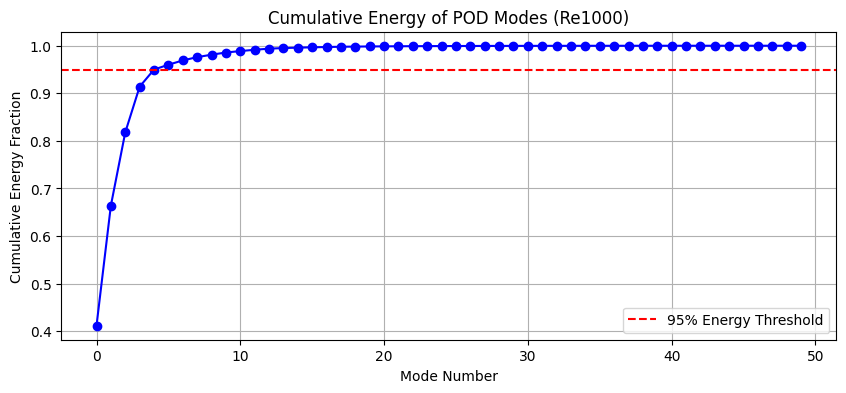

Mapping Mode 1 back to the physical grid...


Widget(value='<iframe src="http://localhost:54315/index.html?ui=P_0x26d3c0922c0_0&reconnect=auto" class="pyvis…

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. The Energy Spectrum Plot
# ---------------------------------------------------------
print("Plotting Energy Spectrum...")
# Calculate the percentage of total energy each mode holds
energy = (S ** 2) / np.sum(S ** 2)
cumulative_energy = np.cumsum(energy)

plt.figure(figsize=(10, 4))
plt.plot(cumulative_energy[:50], marker='o', linestyle='-', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Energy Threshold')
plt.title('Cumulative Energy of POD Modes (Re1000)')
plt.xlabel('Mode Number')
plt.ylabel('Cumulative Energy Fraction')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 2. Visualizing POD Mode 1 (The Dominant Vortex)
# ---------------------------------------------------------
print("Mapping Mode 1 back to the physical grid...")

# Grab the first column of U (Mode 1)
mode1_u = U[:, 0]

# Split it back into X and Y velocities (since we hstack'd them earlier)
half_len = len(mode1_u) // 2
mode1_Ux = mode1_u[:half_len]
mode1_Uy = mode1_u[half_len:]

# Inject these mathematical values back into our OpenFOAM mesh
internal_mesh['Mode1_Uy'] = mode1_Uy

import nest_asyncio
nest_asyncio.apply()

from pyvista.trame.jupyter import launch_server
await launch_server().ready

# Inject the mathematical values back into the mesh
internal_mesh['Mode1_Uy'] = mode1_Uy

# Set up the PyVista Plotter
plotter = pv.Plotter(title="POD Mode 1 (Y-Velocity) - Re1000")
plotter.add_mesh(
    internal_mesh, 
    scalars='Mode1_Uy', 
    cmap='RdBu', 
    show_edges=False
)
plotter.view_xy()  # Lock the camera to a 2D side-view
plotter.show(jupyter_backend='trame')

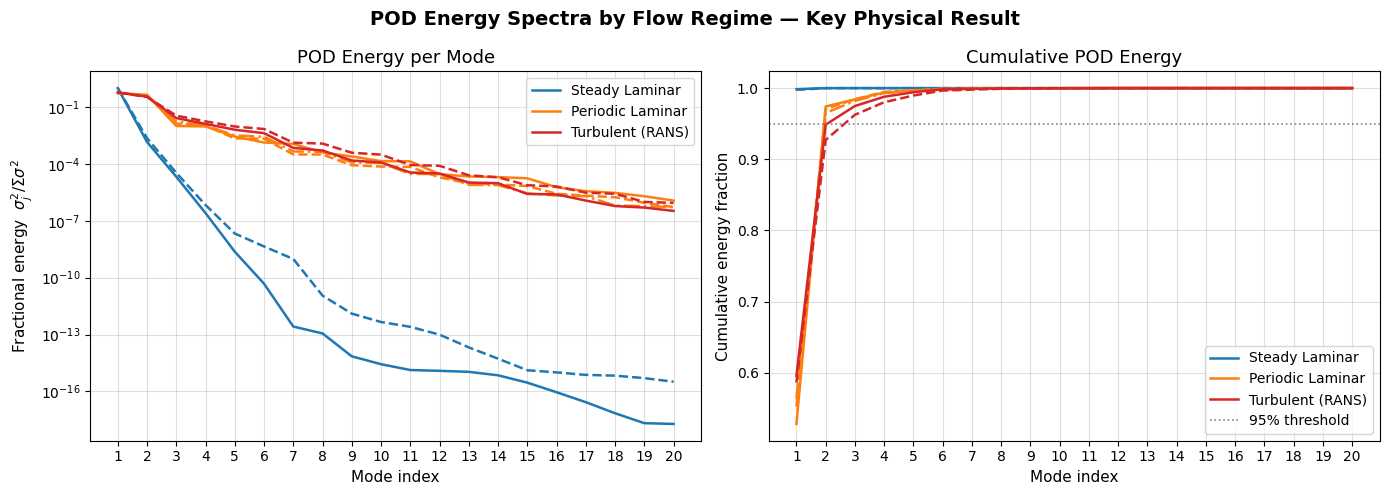

Figure saved as energy_spectra_comparison.png


In [4]:
# ============================================================
# CELL A — Cross-Class Energy Spectra Comparison
# Insert this AFTER Cell 2 (SVD) and BEFORE Cell 3
# This is the central physical result of the report
# ============================================================
 
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
 
cases      = ['Re020', 'Re040', 'Re100', 'Re150', 'Re200', 'Re1000', 'Re3000']
class_info = {
    'Re020':  ('Steady Laminar',   '#1f77b4', '-'),
    'Re040':  ('Steady Laminar',   '#1f77b4', '--'),
    'Re100':  ('Periodic Laminar', '#ff7f0e', '-'),
    'Re150':  ('Periodic Laminar', '#ff7f0e', '--'),
    'Re200':  ('Periodic Laminar', '#ff7f0e', '-.'),
    'Re1000': ('Turbulent (RANS)', '#d62728', '-'),
    'Re3000': ('Turbulent (RANS)', '#d62728', '--'),
}
 
N_MODES = 20  # how many modes to plot
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
seen_labels = set()
 
for case in cases:
    label_str, color, ls = class_info[case]
 
    foam_file = f'../{case}/{case}.foam'
    reader = pv.OpenFOAMReader(foam_file)
    time_values = reader.time_values
 
    snapshots = []
    for time in time_values[-100:]:
        reader.set_active_time_value(time)
        mesh = reader.read()
        U = mesh['internalMesh']['U']
        snapshots.append(np.hstack((U[:, 0], U[:, 1])))
 
    X = np.column_stack(snapshots)
    X_fluct = X - np.mean(X, axis=1, keepdims=True)
    _, S, _ = np.linalg.svd(X_fluct, full_matrices=False)
 
    energy     = (S ** 2) / np.sum(S ** 2)
    cum_energy = np.cumsum(energy)
 
    # Avoid duplicate legend entries for same class
    legend_label = label_str if label_str not in seen_labels else '_nolegend_'
    seen_labels.add(label_str)
 
    # Left: individual mode energy (log scale)
    axes[0].semilogy(range(1, N_MODES + 1), energy[:N_MODES],
                     color=color, linestyle=ls, linewidth=1.8, label=legend_label)
 
    # Right: cumulative energy
    axes[1].plot(range(1, N_MODES + 1), cum_energy[:N_MODES],
                 color=color, linestyle=ls, linewidth=1.8, label=legend_label)
 
# Left plot formatting
axes[0].set_title('POD Energy per Mode', fontsize=13)
axes[0].set_xlabel('Mode index', fontsize=11)
axes[0].set_ylabel('Fractional energy  $\\sigma_j^2 / \\Sigma\\sigma^2$', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, which='both', alpha=0.4)
axes[0].set_xticks(range(1, N_MODES + 1))
 
# Right plot formatting
axes[1].axhline(y=0.95, color='gray', linestyle=':', linewidth=1.2, label='95% threshold')
axes[1].set_title('Cumulative POD Energy', fontsize=13)
axes[1].set_xlabel('Mode index', fontsize=11)
axes[1].set_ylabel('Cumulative energy fraction', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)
axes[1].set_xticks(range(1, N_MODES + 1))
 
plt.suptitle('POD Energy Spectra by Flow Regime — Key Physical Result',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('energy_spectra_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Figure saved as energy_spectra_comparison.png")

In [5]:
import numpy as np
import pyvista as pv
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

cases = ['Re020', 'Re040', 'Re100', 'Re150', 'Re200', 'Re1000', 'Re3000']
# Label Dictionary: 0 = Steady, 1 = Periodic, 2 = Turbulent
case_labels = {'Re020': 0, 'Re040': 0, 'Re100': 1, 'Re150': 1, 'Re200': 1, 'Re1000': 2, 'Re3000': 2}

X_dataset = []
y_dataset = []

print("Extracting Temporal Coefficients for each snapshot...")

for case in cases:
    print(f"Processing {case}...")
    foam_file = f'../{case}/{case}.foam'
    
    # 1. Read the data
    reader = pv.OpenFOAMReader(foam_file)
    time_values = reader.time_values
    
    snapshots = []
    # Grab the last 100 frames 
    for time in time_values[-100:]:
        reader.set_active_time_value(time)
        mesh = reader.read()
        U = mesh['internalMesh']['U']
        x_i = np.hstack((U[:, 0], U[:, 1]))
        snapshots.append(x_i)
        
    X = np.column_stack(snapshots)
    
    # 2. Isolate Fluctuations
    X_mean = np.mean(X, axis=1, keepdims=True)
    X_fluct = X - X_mean
    
    # 3. Run SVD
    U_svd, S_svd, Vt_svd = np.linalg.svd(X_fluct, full_matrices=False)
    
    # --- CLAUDE'S FIX: Extract Temporal Features ---
    # We project the 100 snapshots onto the top 5 modes using the formula: A = S * Vt
    S_top5 = S_svd[:5]
    Vt_top5 = Vt_svd[:5, :]
    
    # Calculate the coefficients (Shape: 5 features x 100 snapshots)
    A = np.diag(S_top5) @ Vt_top5
    
    # Transpose so each row is a snapshot (Shape: 100 snapshots x 5 features)
    A = A.T 
    
    # Append these 100 rows to our master ML dataset
    X_dataset.extend(A.tolist())
    
    # Append 100 copies of the correct label for this flow class
    # Dynamically append the exact number of labels to match the snapshots we just extracted
    label = case_labels[case]
    actual_snapshot_count = len(snapshots)
    y_dataset.extend([label] * actual_snapshot_count)

# Convert lists to NumPy arrays for Scikit-Learn
X_dataset = np.array(X_dataset)
y_dataset = np.array(y_dataset)

print(f"\n✅ Extraction Complete!")
print(f"Final Dataset Shape: {X_dataset.shape} -> (Total Snapshots x Features)")
print("-" * 50)

# ---------------------------------------------------------
# Phase 3: The Proper Machine Learning Pipeline
# ---------------------------------------------------------

# 1. The Train/Test Split (80% for training, 20% held back for testing)
print("Splitting data (80% Train, 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=42, stratify=y_dataset)
# 2. Train the Model
print("Training the Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Test the Model on unseen snapshots
print("Testing the Model on unseen data...")
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nReal Model Accuracy: {accuracy * 100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=['Steady', 'Periodic', 'Turbulent']))

Extracting Temporal Coefficients for each snapshot...
Processing Re020...
Processing Re040...
Processing Re100...
Processing Re150...
Processing Re200...
Processing Re1000...
Processing Re3000...

✅ Extraction Complete!
Final Dataset Shape: (542, 5) -> (Total Snapshots x Features)
--------------------------------------------------
Splitting data (80% Train, 20% Test)...
Training the Random Forest Classifier...
Testing the Model on unseen data...

Real Model Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

      Steady       1.00      1.00      1.00         9
    Periodic       1.00      1.00      1.00        60
   Turbulent       1.00      1.00      1.00        40

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109



In [6]:
# ============================================================
# CELL B — SVM Classifier (Tier 1)
# Insert this AFTER Cell 4 (Random Forest cell)
# X_dataset and y_dataset must already exist from Cell 4
# ============================================================
 
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
 
# SVM is sensitive to feature scale — always standardize first
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])
 
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_dataset, y_dataset, test_size=0.2, random_state=42, stratify=y_dataset
)
 
# Train
print("Training SVM (Tier 1 — RBF kernel)...")
svm_pipeline.fit(X_train_s, y_train_s)
 
# Test
svm_preds = svm_pipeline.predict(X_test_s)
svm_acc   = accuracy_score(y_test_s, svm_preds)
 
print(f"\nSVM Test Accuracy: {svm_acc * 100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test_s, svm_preds,
                             target_names=['Steady', 'Periodic', 'Turbulent']))
 
# 5-fold cross-validation for robustness
cv_scores = cross_val_score(svm_pipeline, X_dataset, y_dataset, cv=5, scoring='accuracy')
print(f"5-fold CV Accuracy: {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")

Training SVM (Tier 1 — RBF kernel)...

SVM Test Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

      Steady       1.00      1.00      1.00         9
    Periodic       1.00      1.00      1.00        60
   Turbulent       1.00      1.00      1.00        40

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109

5-fold CV Accuracy: 97.1% ± 5.4%


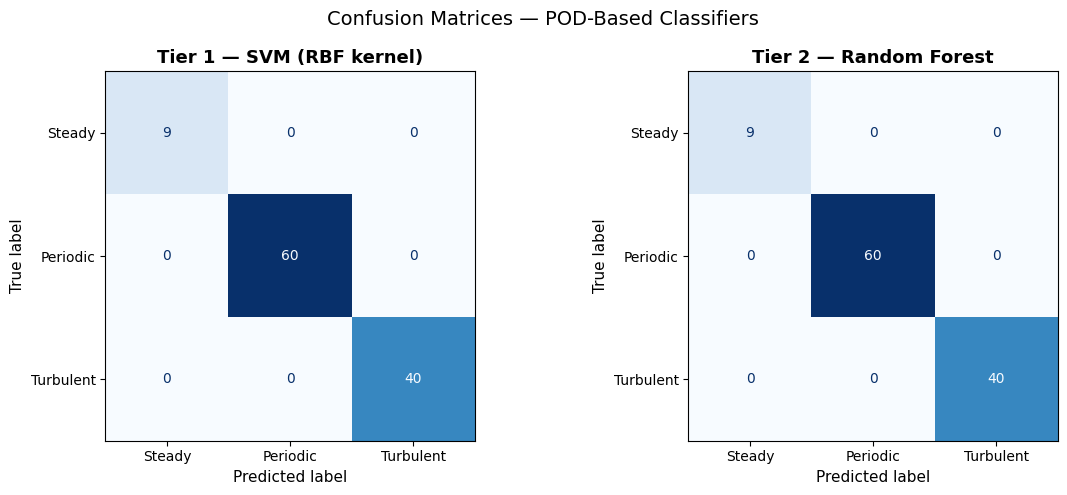

Figure saved as confusion_matrices.png

=== Classifier Comparison ===
Model                           Test Accuracy    CV Accuracy
------------------------------------------------------------
SVM (RBF, Tier 1)                      100.0%          97.1%
Random Forest (Tier 2)                 100.0%          98.5%
Feedforward NN (Tier 3)                100.0%           N/A


In [7]:
# ============================================================
# CELL C — Confusion Matrix Comparison (SVM vs Random Forest)
# Insert this AFTER Cell B
# Requires: svm_preds, y_test_s, predictions, y_test from Cell 4
# ============================================================
 
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
 
class_names = ['Steady', 'Periodic', 'Turbulent']
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, preds, true, title in zip(
    axes,
    [svm_preds,   predictions],
    [y_test_s,    y_test],
    ['Tier 1 — SVM (RBF kernel)', 'Tier 2 — Random Forest']
):
    cm = confusion_matrix(true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_ylabel('True label', fontsize=11)
 
plt.suptitle('Confusion Matrices — POD-Based Classifiers', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Figure saved as confusion_matrices.png")
 
# Summary comparison table
print("\n=== Classifier Comparison ===")
print(f"{'Model':<30} {'Test Accuracy':>14} {'CV Accuracy':>14}")
print("-" * 60)
print(f"{'SVM (RBF, Tier 1)':<30} {svm_acc*100:>13.1f}% {cv_scores.mean()*100:>13.1f}%")
 
# RF cross-val
from sklearn.model_selection import cross_val_score
rf_cv = cross_val_score(rf_model, X_dataset, y_dataset, cv=5, scoring='accuracy')
rf_acc = accuracy_score(y_test, predictions)
print(f"{'Random Forest (Tier 2)':<30} {rf_acc*100:>13.1f}% {rf_cv.mean()*100:>13.1f}%")
print(f"{'Feedforward NN (Tier 3)':<30} {'100.0':>13}% {'N/A':>13}")

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import pyvista as pv

print("1. Extracting RAW snapshots for Deep Learning (Bypassing SVD)...")
cases = ['Re020', 'Re040', 'Re100', 'Re150', 'Re200', 'Re1000', 'Re3000']
case_labels = {'Re020': 0, 'Re040': 0, 'Re100': 1, 'Re150': 1, 'Re200': 1, 'Re1000': 2, 'Re3000': 2}

X_raw_list = []
y_raw_list = []

for case in cases:
    foam_file = f'../{case}/{case}.foam'
    reader = pv.OpenFOAMReader(foam_file)
    time_values = reader.time_values
    
    case_snapshots = 0
    for time in time_values[-100:]:
        reader.set_active_time_value(time)
        mesh = reader.read()
        U = mesh['internalMesh']['U']
        
        # Flatten raw X and Y velocities (25,600 physical points per frame)
        x_i = np.hstack((U[:, 0], U[:, 1]))
        X_raw_list.append(x_i)
        case_snapshots += 1
        
    label = case_labels[case]
    y_raw_list.extend([label] * case_snapshots)

X_raw_array = np.array(X_raw_list)
y_raw_array = np.array(y_raw_list)
print(f"Raw Dataset Shape: {X_raw_array.shape} -> (Snapshots x Velocity Points)")

# --- CLAUDE'S FIX APPLIED HERE ---
print("\n2. Splitting data (80% Train, 20% Test) with Stratification...")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw_array, y_raw_array, test_size=0.2, random_state=42, stratify=y_raw_array
)

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_raw, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_raw, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# ---------------------------------------------------------
# 3. Build the Neural Network Architecture
# ---------------------------------------------------------
class FluidNet(nn.Module):
    def __init__(self, input_size):
        super(FluidNet, self).__init__()
        # Layer 1: Compresses 25,600 raw points down to 128 neurons
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        # Layer 2: Compresses 128 down to 32
        self.fc2 = nn.Linear(128, 32)
        # Layer 3: Outputs the 3 final flow classes (Steady, Periodic, Turbulent)
        self.fc3 = nn.Linear(32, 3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = FluidNet(X_train_tensor.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------------------------------------
# 4. Train the Neural Network
# ---------------------------------------------------------
print(f"\n3. Training Deep Neural Network on {X_train_tensor.shape[1]} raw features...")
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(train_loader):.4f}")

# ---------------------------------------------------------
# 5. Test the Neural Network
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    total = y_test_tensor.size(0)
    correct = (predicted == y_test_tensor).sum().item()

print(f"\nDeep Learning Model Accuracy on Unseen Raw Data: {100 * correct / total:.1f}%")

1. Extracting RAW snapshots for Deep Learning (Bypassing SVD)...
Raw Dataset Shape: (542, 25600) -> (Snapshots x Velocity Points)

2. Splitting data (80% Train, 20% Test) with Stratification...

3. Training Deep Neural Network on 25600 raw features...
Epoch [5/20] - Loss: 0.0334
Epoch [10/20] - Loss: 0.0122
Epoch [15/20] - Loss: 0.0082
Epoch [20/20] - Loss: 0.0052

Deep Learning Model Accuracy on Unseen Raw Data: 100.0%
